# Notebook 1 — Structure and Stationarity of PETR4.SA

**Learning objectives**

- Decompose a series additively, multiplicatively, and via STL — and learn to
  read the output honestly when the data has no real seasonal cycle.
- Test stationarity (ADF + KPSS) and read the two tests jointly.
- Remediate non-stationarity via differencing, log + diff, and detrending; verify.
- Stabilise variance with Box-Cox and Yeo-Johnson power transformations.

**Subject.** Daily PETR4.SA series cached by Notebook 0.
This notebook follows Atwan Cookbook Ch8 pp. 287–308.

<!-- intro:auto -->
## Notebook 1 — Structure and Stationarity of PETR4.SA

<div style="background:rgba(66,133,244,0.08);border-left:4px solid #4285f4;border-radius:6px;padding:12px 16px;margin:8px 0;">
  <div style="text-align:center;font-weight:600;margin-bottom:6px;color:#4285f4;">Coverage</div>
  <div style="color:inherit;">This report applies classical time-series diagnostics to the full PETR4.SA daily price history (2000–2026) cached by Notebook 0: seasonal decomposition reveals whether a calendar cycle exists, stationarity tests determine which representation of the series is model-ready, remediation transforms confirm the correct working series, visual evidence cross-validates the formal tests, and power transformations characterise distributional shape ahead of Notebook 2.</div>
</div>

<div style="max-width:560px;margin:12px 0;display:flex;flex-direction:column;">
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #8430ce;display:flex;align-items:center;justify-content:center;color:#8430ce;font-weight:600;">T</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#8430ce;">Theory — What is a time series?</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Definition, the four classical components (trend, seasonality, cyclical, residual), and the additive vs multiplicative decomposition.</div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #4285f4;display:flex;align-items:center;justify-content:center;color:#4285f4;font-weight:600;">1</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#4285f4;">Act 1 — Data reload</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Load the cached PETR4.SA CSV and derive the working price and return series.</div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #34a853;display:flex;align-items:center;justify-content:center;color:#34a853;font-weight:600;">2</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#34a853;">Act 2 — Seasonal decomposition</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Apply additive and multiplicative decomposition to monthly closes; establish whether a 12-month cycle is present.</div>
      <div style="display:flex;flex-wrap:wrap;gap:6px;margin-top:8px;">
        <span style="border:1px solid #34a853;color:#34a853;background:rgba(52,168,83,0.08);border-radius:999px;padding:4px 10px;font-size:0.85em;">Additive vs Multiplicative</span>
      </div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #e37400;display:flex;align-items:center;justify-content:center;color:#e37400;font-weight:600;">3</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#e37400;">Act 3 — STL decomposition</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">LOESS-based decomposition with robust weighting; contrast with classical seasonal_decompose.</div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #8430ce;display:flex;align-items:center;justify-content:center;color:#8430ce;font-weight:600;">4</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#8430ce;">Act 4 — Stationarity tests</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Run ADF + KPSS jointly on price, log-price, and log returns; read the combined decision table.</div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #4285f4;display:flex;align-items:center;justify-content:center;color:#4285f4;font-weight:600;">5</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#4285f4;">Act 5 — Remediation for non-stationarity</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Compare first diff, log + diff, and linear detrend; select the unambiguously stationary transform.</div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #34a853;display:flex;align-items:center;justify-content:center;color:#34a853;font-weight:600;">6</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#34a853;">Act 6 — Visual evidence</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Rolling and expanding moments, monthly-return heatmap, and pre/post-COVID KDE cross-validate the formal tests.</div>
      <div style="display:flex;flex-wrap:wrap;gap:6px;margin-top:8px;">
        <span style="border:1px solid #34a853;color:#34a853;background:rgba(52,168,83,0.08);border-radius:999px;padding:4px 10px;font-size:0.85em;">Rolling moments</span>
        <span style="border:1px solid #34a853;color:#34a853;background:rgba(52,168,83,0.08);border-radius:999px;padding:4px 10px;font-size:0.85em;">Monthly heatmap</span>
        <span style="border:1px solid #34a853;color:#34a853;background:rgba(52,168,83,0.08);border-radius:999px;padding:4px 10px;font-size:0.85em;">Pre/post-COVID KDE</span>
      </div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #e37400;display:flex;align-items:center;justify-content:center;color:#e37400;font-weight:600;">7</div>
      <div style="width:2px;flex:1;background:rgba(128,128,128,0.25);margin-top:4px;"></div>
    </div>
    <div style="padding-bottom:16px;">
      <div style="font-weight:600;color:#e37400;">Act 7 — Power transformations</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Box-Cox on price and volume, Yeo-Johnson on log returns; measure how far each series deviates from the identity transform.</div>
    </div>
  </div>
  <div style="display:flex;align-items:flex-start;gap:12px;">
    <div style="display:flex;flex-direction:column;align-items:center;align-self:stretch;">
      <div style="width:36px;height:36px;border-radius:50%;border:2px solid #8430ce;display:flex;align-items:center;justify-content:center;color:#8430ce;font-weight:600;">8</div>
    </div>
    <div>
      <div style="font-weight:600;color:#8430ce;">Act 8 — Interactive view</div>
      <div style="color:inherit;opacity:0.7;margin-top:2px;">Plotly range-slider chart for exploratory navigation of the full 2000–2026 price history.</div>
    </div>
  </div>
</div>

Here we discover that PETR4.SA has no usable seasonal cycle under any decomposition method, that raw prices and log-prices are non-stationary by both ADF and KPSS tests, and that **log returns (log + first difference) are the sole transform that passes both tests unambiguously**. First differencing alone and linear detrending both fail the joint criterion. Visually, log returns are stationary in mean but exhibit clear volatility clustering and a distributional shift around COVID — a heteroskedastic structure that Notebook 2 quantifies. Power transforms confirm that all three series (price, volume, log returns) benefit from a variance-stabilising transformation, with Box-Cox λ values far from the identity for price and volume.

## Theory — What is a time series?

<div style="background:rgba(66,133,244,0.08);border-left:5px solid #4285f4;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(66,133,244,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#4285f4;">Coverage</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">Before any decomposition or stationarity test, fix the vocabulary: a time series is a sequence of observations on a variable indexed by time, treated as a realisation of an underlying stochastic process [1][3]. Classical analysis breaks the observed series into a small set of interpretable components — trend, seasonality, cyclical, and residual — and combines them through an additive or multiplicative decomposition [1][2].</div></div>

<div style="background:rgba(52,168,83,0.08);border-left:5px solid #34a853;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(52,168,83,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#34a853;">Definition</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">In the popular sense, a time series is a sequence of observations on a variable over time; in the statistical sense, it is a random variable ordered in time [3]. The series $y_t$ is analysed as the realisation of a stochastic process and is routinely decomposed into interpretable components that reveal its underlying structure before forecasting or formal modelling [1].</div></div>

### The four classical components

<div style="background:rgba(66,133,244,0.08);border-left:5px solid #4285f4;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(66,133,244,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#4285f4;">Trend $T_t$</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">The long-term, smooth direction of the series — the persistent upward, downward, or horizontal movement that captures the underlying growth or decline in the mean level of the process [1]. Formally a deterministic function of time, often modelled as a polynomial in $t$ or via smoothing, it is what remains after shorter-term periodic and irregular movements are averaged out [2].</div></div>

<div style="background:rgba(52,168,83,0.08);border-left:5px solid #34a853;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(52,168,83,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#34a853;">Seasonality $S_t$</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">A regular, repeating pattern at fixed and known calendar intervals — months within a year, days within a week, hours within a day — driven by institutional, climatic, or cultural factors [1]. Seasonality captures within-period variation that is predictable in timing and shape (e.g., retail sales spiking in Q4) and is distinct from trend because it does not alter the long-run direction of the series [4].</div></div>

<div style="background:rgba(249,171,0,0.08);border-left:5px solid #f9ab00;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(249,171,0,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#f9ab00;">Cyclical $C_t$</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">Oscillations longer than the seasonal period and not of fixed length — expansions and contractions tied to business cycles or other low-frequency fluctuations, typically spanning several years [2]. Unlike seasonality, cycles are quasi-periodic: their duration and amplitude vary from one occurrence to the next, requiring statistical modelling rather than calendar-based adjustment [2].</div></div>

<div style="background:rgba(147,52,230,0.08);border-left:5px solid #9334e6;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(147,52,230,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#9334e6;">Residual $R_t$</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">The leftover variation that cannot be attributed to trend, seasonality, or cyclical forces — the random, unpredictable shocks at each time point [1]. Assumed to be a stationary, zero-mean random process with no systematic pattern; in an ideal decomposition, the residual should look like white noise, indicating that all structured variation has been successfully extracted [1].</div></div>

### Classical decomposition

The additive model expresses the observed series as the sum of its components,

$$y_t = T_t + S_t + C_t + R_t$$

assuming that the magnitude of each component does not depend on the level of the series [2]. When the amplitude of seasonal or cyclical swings grows with the trend, the multiplicative form is used instead,

$$y_t = T_t \times S_t \times C_t \times R_t$$

and a log transformation converts it back to additive form [2]. The decomposition serves as a diagnostic and preprocessing step: by isolating each source of variation, the analyst can decide whether to remove trend and seasonality (e.g., through differencing or seasonal adjustment) to achieve stationarity, or to incorporate them explicitly into a model [1].

<div style="background:rgba(249,171,0,0.08);border-left:5px solid #f9ab00;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(249,171,0,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#f9ab00;">Three vs four components — sources disagree</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">Atwan frames a time series as three main components — trend, seasonality, and residual — treating the cyclical component as an optional pattern some series may exhibit over longer, irregular intervals [1]. Pesaran lists four — trend, seasonal, cyclical, and residual — as the standard building blocks of classical decomposition, reflecting the econometric tradition of explicitly modelling business-cycle fluctuations [2]. Both agree that the residual is the irreducible random element and that trend and seasonality are the most routinely estimated and removed components.</div></div>

---

**References**

1. Atwan, T. A. — *Time Series Analysis with Python Cookbook*, 2nd ed. (Packt, 2026) — ch08, *Decomposing time series data*.
2. Pesaran, M. H. — *Time Series and Panel Data Econometrics* — ch12, §12.5 *Classical decomposition of time series*.
3. Das, P. — *Econometrics in Theory and Practice: Analysis of Cross Section, Time Series and Panel Data with Stata 15.1* — ch09, §9.1 *Introduction*.
4. Wooldridge, J. M. — *Introductory Econometrics — A Modern Approach* — ch10, §10-5e *Seasonality*.

In [13]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import PowerTransformer

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import statsmodels.api as sm

import plotly.express as px

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("dark_background")
_BG = "#000000"
sns.set_theme(context="notebook", style="darkgrid", rc={
    "axes.facecolor": _BG, "figure.facecolor": _BG, "savefig.facecolor": _BG,
    "axes.edgecolor": "#cccccc", "axes.labelcolor": "#eeeeee",
    "axes.titlecolor": "#eeeeee", "xtick.color": "#cccccc",
    "ytick.color": "#cccccc", "text.color": "#eeeeee",
    "grid.color": "#222222", "legend.facecolor": "#111111",
    "legend.edgecolor": "#333333", "patch.edgecolor": "#cccccc",
})
plt.rcParams["figure.figsize"] = (11, 4)

import plotly.io as pio
_tpl = pio.templates["plotly_dark"]
_tpl.layout.paper_bgcolor = _BG
_tpl.layout.plot_bgcolor = _BG
pio.templates["black_bg"] = _tpl
pio.templates.default = "black_bg"

np.random.seed(42)

## Reload cached data

Notebook 0 caches PETR4.SA to `data/PETR4_SA.csv`. Run Notebook 0 first if the
cache is missing.

In [14]:
CSV_PATH = Path("data/PETR4_SA.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"{CSV_PATH} not found — run Notebook 0 first.")
df = pd.read_csv(CSV_PATH, index_col="Date", parse_dates=True)
price = df["Adj Close"]
ret_log = np.log(price / price.shift()).dropna()
ret_simple = price.pct_change().dropna()
print(f"PETR4 rows: {len(df):,} | {df.index.min().date()} → {df.index.max().date()}")
df.head()

PETR4 rows: 6,624 | 2000-01-03 → 2026-05-25


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-03,1.105877,5.875,5.875,5.875,5.875,35389440000
2000-01-04,1.044701,5.550,5.550,5.550,5.550,28861440000
2000-01-05,1.034160,5.494,5.494,5.494,5.494,43033600000
2000-01-06,1.030583,5.475,5.475,5.475,5.475,34055680000
2000-01-07,1.035289,5.500,5.500,5.500,5.500,20912640000


## 1.2 — Seasonal decomposition

### PETR4 monthly close — additive vs multiplicative

Equities like PETR4 have no fixed annual cycle: share prices are driven by
macro events, earnings, and commodity prices, not by a calendar rhythm.
Nonetheless, applying `seasonal_decompose` to PETR4 is pedagogically
valuable — it teaches us **what "no seasonality" looks like in the output**
and reinforces when (and when not) to trust the seasonal component.

We resample daily closes to the last business day of each month
(`resample("ME").last()`) and run both additive and multiplicative
decompositions with `period=12`, producing a 4 × 2 grid.

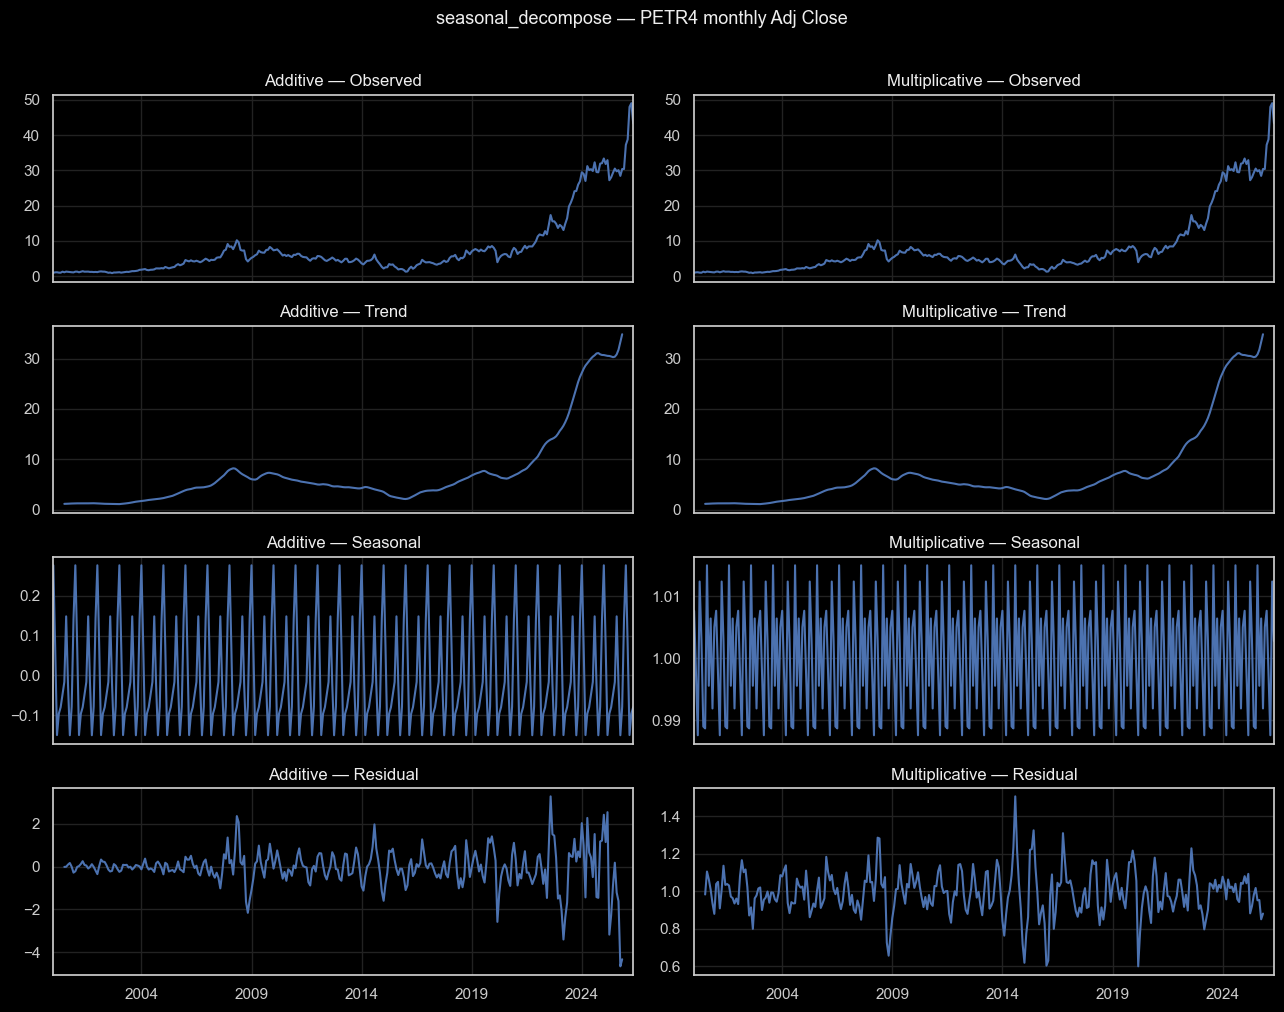

In [15]:
monthly_price = price.resample("ME").last().dropna()

add_dec = seasonal_decompose(monthly_price, model="additive",       period=12)
mul_dec = seasonal_decompose(monthly_price, model="multiplicative", period=12)

fig, axes = plt.subplots(4, 2, figsize=(13, 10), sharex=True)
components = ["observed", "trend", "seasonal", "resid"]
labels     = ["Observed", "Trend", "Seasonal", "Residual"]
for j, (name, dec) in enumerate([("Additive", add_dec), ("Multiplicative", mul_dec)]):
    for i, (comp, label) in enumerate(zip(components, labels)):
        getattr(dec, comp).plot(ax=axes[i, j])
        axes[i, j].set_title(f"{name} — {label}")
        axes[i, j].set_xlabel("")
fig.suptitle("seasonal_decompose — PETR4 monthly Adj Close", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

**Plot analysis — additive vs multiplicative.**
The seasonal component is small relative to the trend under **both** models,
and the residual carries most of the variance — empirical evidence that PETR4
has no usable 12-month cycle.

- **Multiplicative residuals** hover close to 1 (the multiplicative neutral
  value), meaning the model explains most of the level variation even though
  there is no real season.
- **Additive residuals** are tighter in absolute scale because price itself
  is dominated by a strong trend.
- Neither model is "right" here: there is no genuine seasonal signal for
  either to recover. The honest reading of these plots is the teaching point.

## 1.3 — STL (Seasonal-Trend decomposition using LOESS)

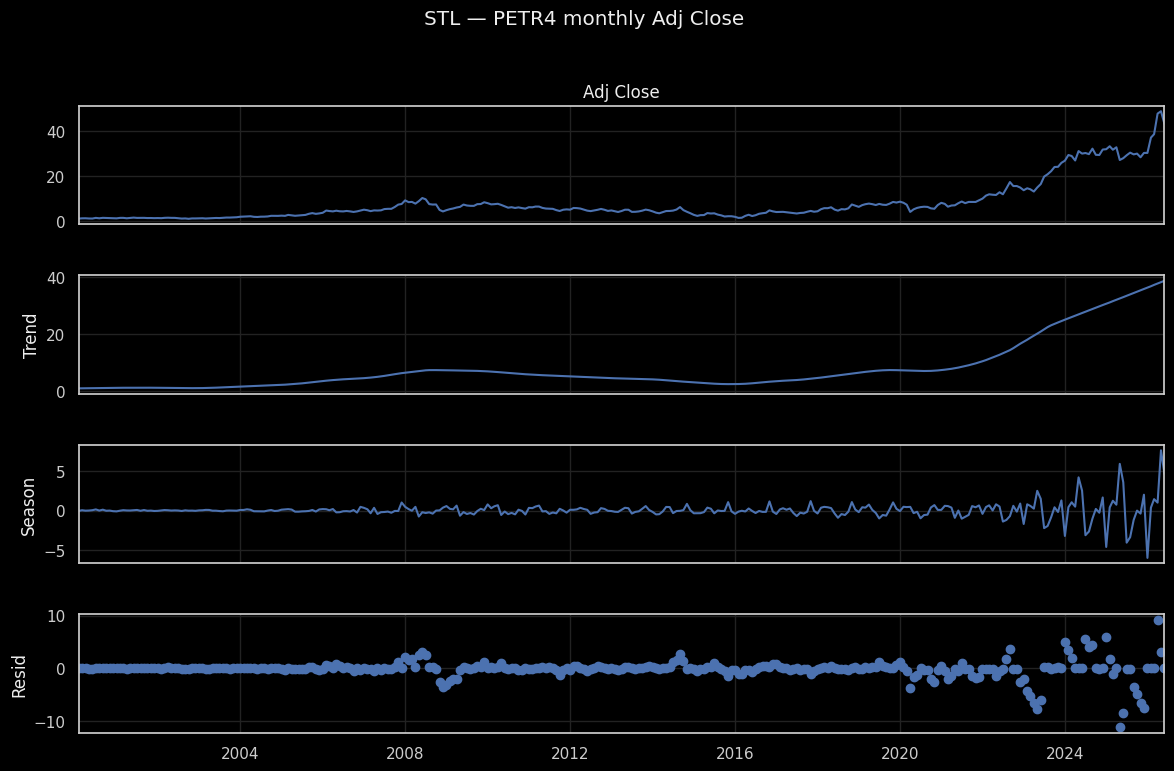

In [4]:
stl = STL(monthly_price, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL — PETR4 monthly Adj Close", y=1.02)
plt.show()

**Plot analysis — STL.** Compared to `seasonal_decompose`, STL produces a
smoother trend (LOESS-fitted) and allows the seasonal component to
evolve over time rather than repeating identically each year.
On PETR4, the seasonal amplitude remains small relative to trend + residual,
confirming the §1.2 finding: there is no genuine 12-month cycle.
STL is the safer default for real-world data because `robust=True` downweights
outlier periods, but it cannot manufacture seasonality the data does not contain.

## 1.4 — Stationarity tests

In [3]:
def adf_kpss(series: pd.Series, name: str) -> dict:
    s = series.dropna()
    adf = adfuller(s, autolag="AIC")
    kp  = kpss(s, regression="c", nlags="auto")
    adf_stat, adf_p = adf[0], adf[1]
    kp_stat,  kp_p  = kp[0], kp[1]
    if adf_p < 0.05 and kp_p > 0.05:
        decision = "stationary"
    elif adf_p > 0.05 and kp_p < 0.05:
        decision = "non-stationary"
    else:
        decision = "inconclusive — apply remediation"
    return {
        "series":    name,
        "ADF stat":  adf_stat, "ADF p":  adf_p,
        "KPSS stat": kp_stat,  "KPSS p": kp_p,
        "decision":  decision,
    }

pd.DataFrame([
    adf_kpss(price,            "Adj Close"),
    adf_kpss(np.log(price),    "log(price)"),
    adf_kpss(ret_log,          "log returns"),
])

C:\Users\iohan\AppData\Local\Temp\ipykernel_24116\3883816950.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")
C:\Users\iohan\AppData\Local\Temp\ipykernel_24116\3883816950.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")
C:\Users\iohan\AppData\Local\Temp\ipykernel_24116\3883816950.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")


,series,ADF stat,ADF p,KPSS stat,KPSS p,decision
0,Adj Close,2.263110,0.998931,6.500784,0.01,non-stationary
1,log(price),-0.612220,0.868197,8.324811,0.01,non-stationary
2,log returns,-29.499187,0.000000,0.102686,0.10,stationary


**Interpretation.** Adj Close and `log(price)` register as non-stationary;
log returns register as stationary. Modelling returns rather than prices is
the standard practice.

## 1.5 — Remediation for non-stationarity

In [4]:
diff1       = price.diff().dropna()
log_diff1   = np.log(price).diff().dropna()
detrended   = sm.OLS(price.values,
                     sm.add_constant(np.arange(len(price), dtype=float))).fit().resid
detrended   = pd.Series(detrended, index=price.index, name="detrended")

remediation = pd.DataFrame([
    adf_kpss(price,       "raw price"),
    adf_kpss(diff1,       "first diff"),
    adf_kpss(log_diff1,   "log + first diff"),
    adf_kpss(detrended,   "linear detrend"),
])
remediation

C:\Users\iohan\AppData\Local\Temp\ipykernel_24116\3883816950.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")
C:\Users\iohan\AppData\Local\Temp\ipykernel_24116\3883816950.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")
C:\Users\iohan\AppData\Local\Temp\ipykernel_24116\3883816950.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")


,series,ADF stat,ADF p,KPSS stat,KPSS p,decision
0,raw price,2.263110,9.989305e-01,6.500784,0.01000,non-stationary
1,first diff,-11.790113,9.872456e-22,0.719857,0.01174,inconclusive — apply remediation
2,log + first diff,-29.499187,0.000000e+00,0.102686,0.10000,stationary
3,linear detrend,0.649420,9.887725e-01,1.818782,0.01000,non-stationary


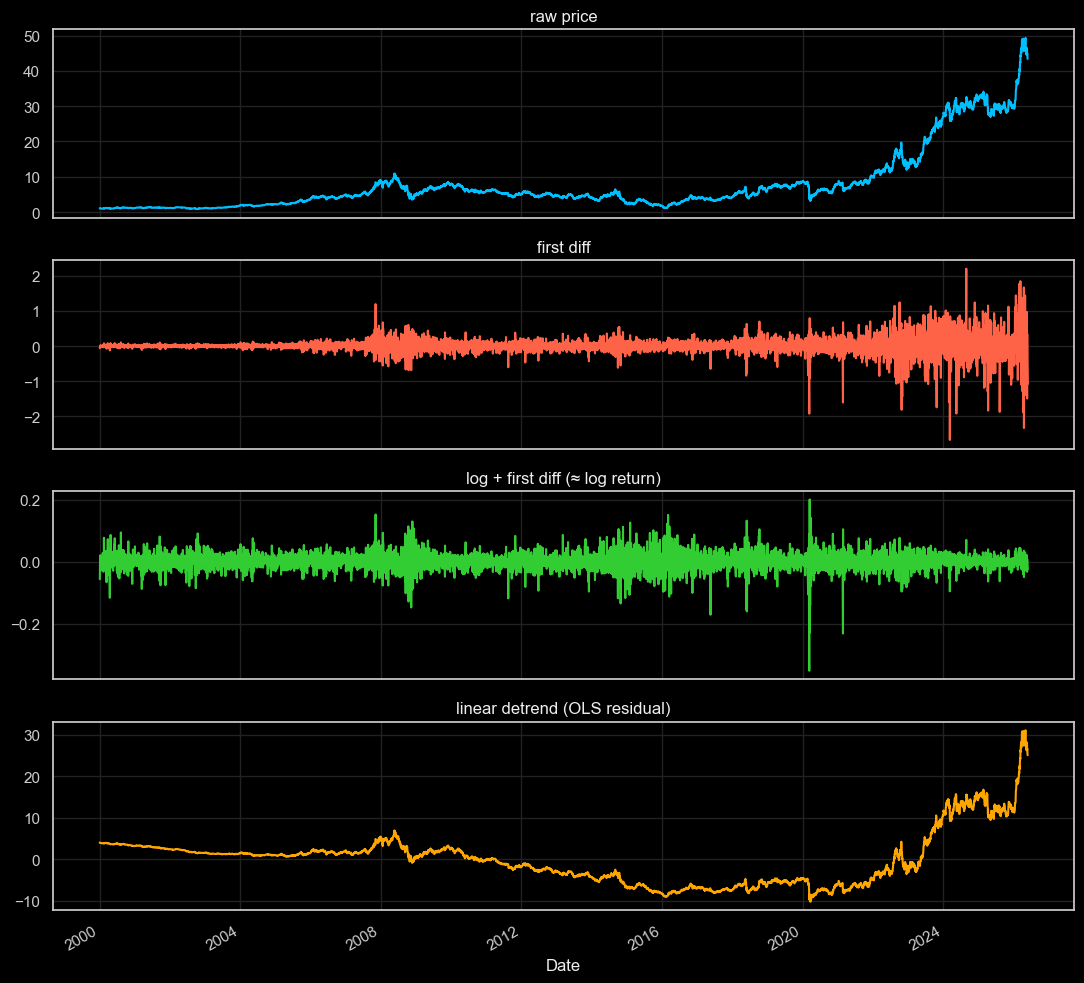

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
price.plot       (ax=axes[0], color="deepskyblue"); axes[0].set_title("raw price")
diff1.plot       (ax=axes[1], color="tomato");      axes[1].set_title("first diff")
log_diff1.plot   (ax=axes[2], color="limegreen");   axes[2].set_title("log + first diff (≈ log return)")
detrended.plot   (ax=axes[3], color="orange");      axes[3].set_title("linear detrend (OLS residual)")
plt.tight_layout(); plt.show()

**Decision.** `log + first diff` (i.e. log returns) is the only candidate
that is unambiguously stationary by both tests; this is what downstream
notebooks model. `first diff` and `detrend` reduce the unit-root signal but
leave residual variance issues that the next notebook will quantify.

## 1.6 — Stationarity through visual evidence

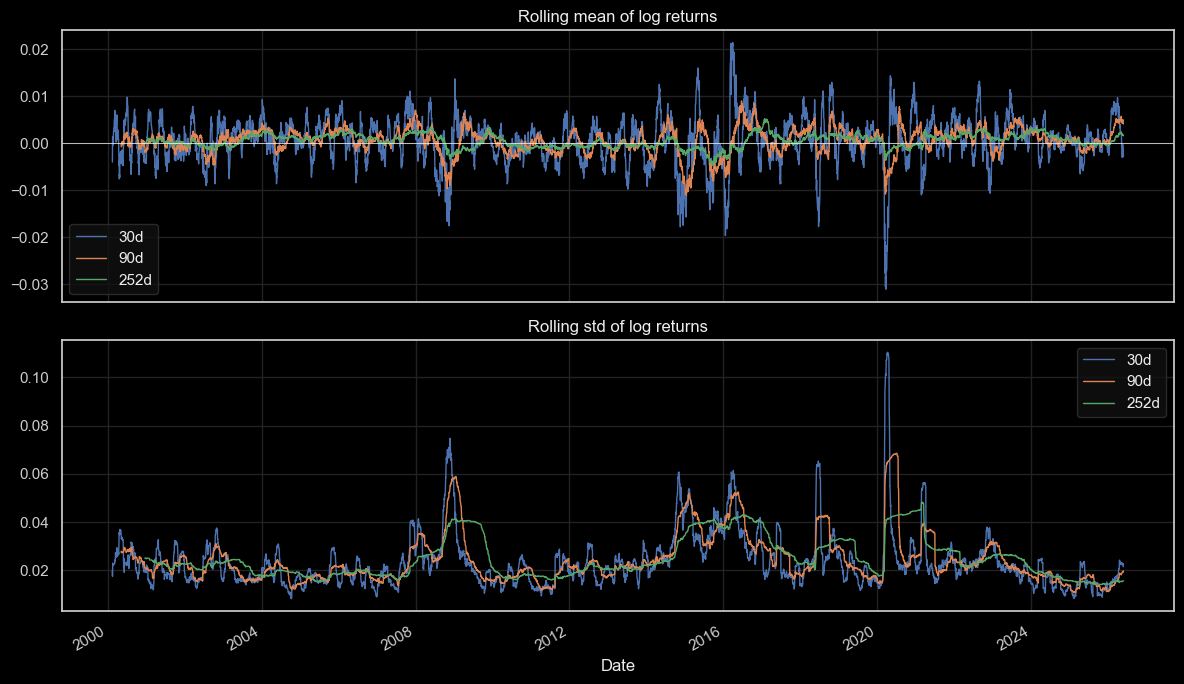

In [6]:
windows = [30, 90, 252]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for w in windows:
    ret_log.rolling(w).mean().plot(ax=axes[0], lw=1, label=f"{w}d")
    ret_log.rolling(w).std().plot(ax=axes[1], lw=1, label=f"{w}d")
axes[0].set_title("Rolling mean of log returns"); axes[0].axhline(0, color="w", lw=0.5); axes[0].legend()
axes[1].set_title("Rolling std of log returns");  axes[1].legend()
plt.tight_layout(); plt.show()

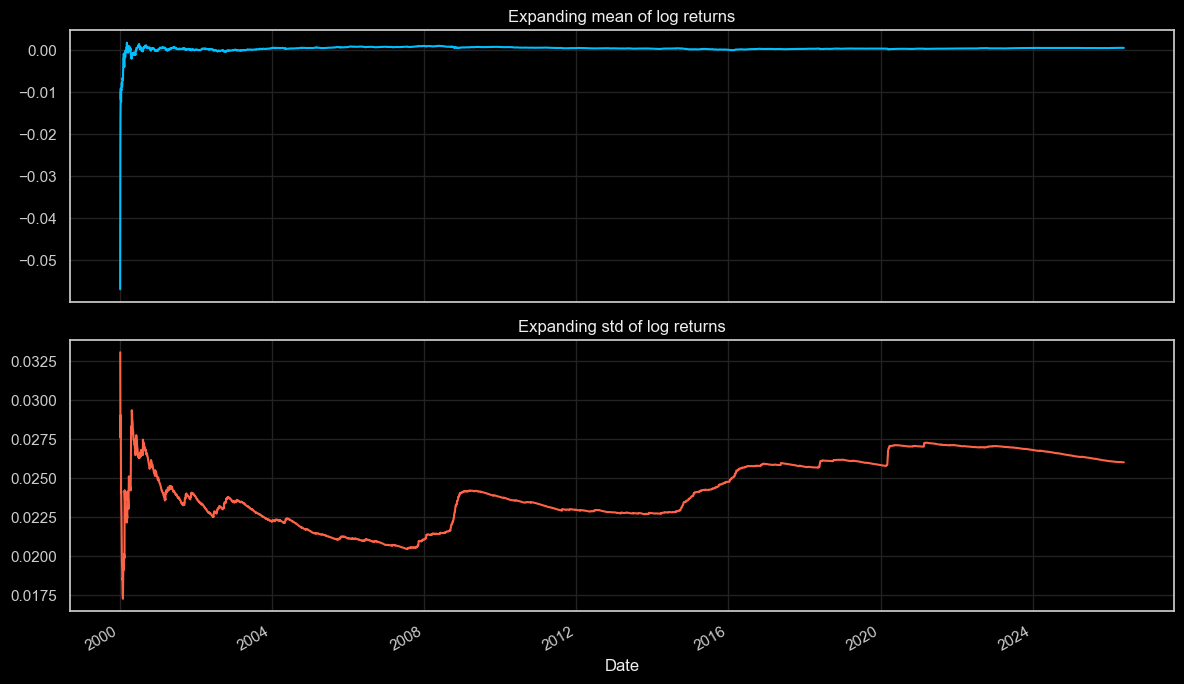

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ret_log.expanding().mean().plot(ax=axes[0], color="deepskyblue")
ret_log.expanding().std().plot (ax=axes[1], color="tomato")
axes[0].set_title("Expanding mean of log returns")
axes[1].set_title("Expanding std of log returns")
plt.tight_layout(); plt.show()

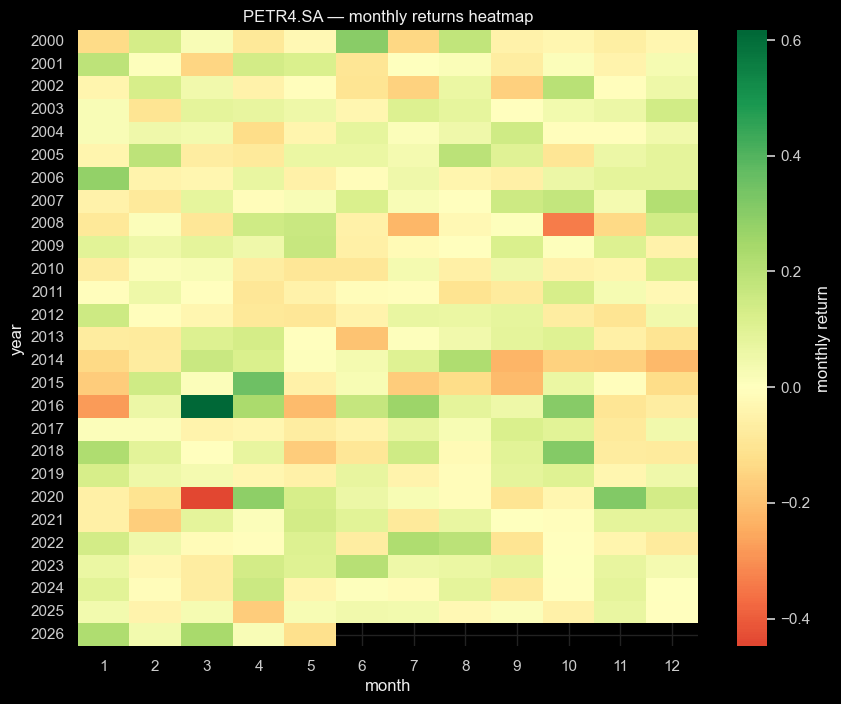

In [8]:
monthly = (1 + ret_simple).resample("ME").prod() - 1
heat = monthly.to_frame("ret")
heat["year"]  = heat.index.year
heat["month"] = heat.index.month
pivot = heat.pivot(index="year", columns="month", values="ret")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0, annot=False,
            cbar_kws={"label": "monthly return"})
ax.set_title("PETR4.SA — monthly returns heatmap")
plt.show()

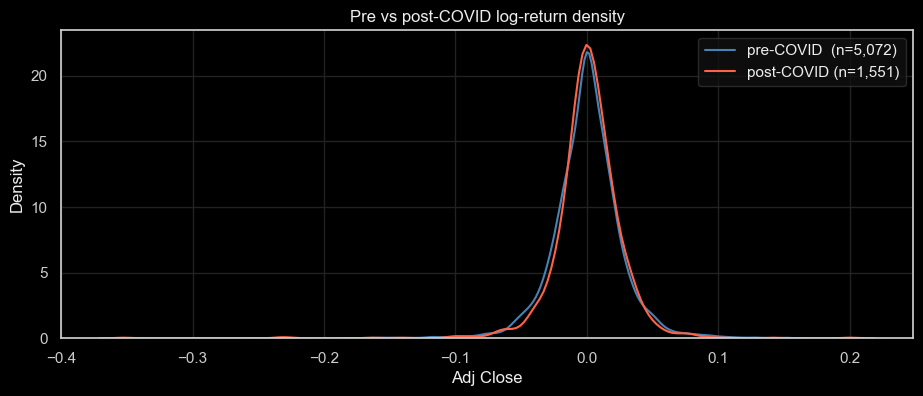

In [9]:
cut = pd.Timestamp("2020-03-01")
pre, post = ret_log.loc[:cut], ret_log.loc[cut:]
fig, ax = plt.subplots()
sns.kdeplot(pre,  ax=ax, color="steelblue", label=f"pre-COVID  (n={len(pre):,})")
sns.kdeplot(post, ax=ax, color="tomato",    label=f"post-COVID (n={len(post):,})")
ax.set_title("Pre vs post-COVID log-return density"); ax.legend()
plt.show()

**Interpretation.** Volatility clusters (rolling std), moments do not
converge (expanding stats), and the COVID cut shifts the distribution. The
visual signal matches the formal tests: returns are stationary on average
but heteroskedastic — addressed in NB2.

## 1.7 — Power transformations: an overview

In [10]:
price_bc, lam_price = boxcox(price.dropna().values)
vol_bc,   lam_vol   = boxcox(df["Volume"].replace(0, np.nan).dropna().values)
ret_yj,   lam_ret   = yeojohnson(ret_log.values)
print(f"Box-Cox     λ (price)        : {lam_price:.4f}")
print(f"Box-Cox     λ (volume)       : {lam_vol:.4f}")
print(f"Yeo-Johnson λ (log returns)  : {lam_ret:.4f}")

Box-Cox     λ (price)        : -0.1240
Box-Cox     λ (volume)       : -0.1918
Yeo-Johnson λ (log returns)  : 2.9794


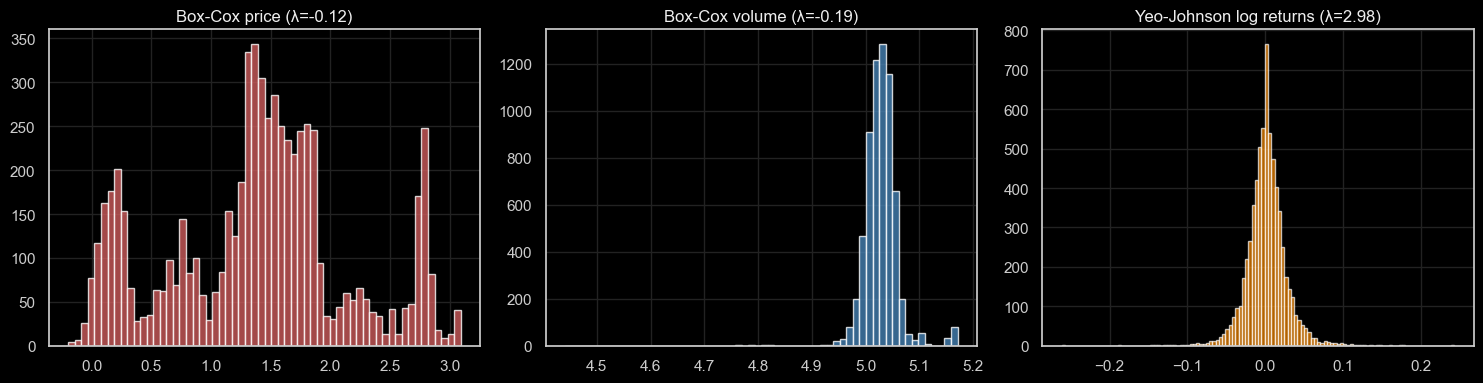

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(price_bc, bins=60, color="indianred", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Box-Cox price (λ={lam_price:.2f})")
axes[1].hist(vol_bc, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_title(f"Box-Cox volume (λ={lam_vol:.2f})")
axes[2].hist(ret_yj, bins=120, color="darkorange", edgecolor="white", alpha=0.7)
axes[2].set_title(f"Yeo-Johnson log returns (λ={lam_ret:.2f})")
plt.tight_layout(); plt.show()

**Interpretation.** All three λ values land away from 1 (the identity),
confirming the raw series benefit from a power transform. The deep dive
(`boxcox_normmax`, `boxcox_normplot`, sklearn parity) lives in NB2 §2.5.

## 1.8 — Interactive view

In [12]:
fig = px.line(price.reset_index(), x="Date", y="Adj Close",
              title="PETR4.SA — Adjusted Close (interactive)",
              template="black_bg")
fig.update_xaxes(rangeslider_visible=True)
fig.show()

<!-- conclusion:auto -->
## Conclusions

- **Act 2 — Seasonal decomposition** — Both additive and multiplicative `seasonal_decompose` (period=12) applied to monthly PETR4 closes show a negligible seasonal component relative to trend and residual; neither model recovers a usable 12-month cycle, confirming that PETR4 is not a seasonally driven series.

- **Act 3 — STL decomposition** — STL with `robust=True` produces a smoother LOESS trend and a time-varying seasonal shape, but the seasonal amplitude remains small relative to trend and residual — consistent with §1.2 and reinforcing that no genuine calendar cycle exists in PETR4.

- **Act 4 — Stationarity tests** — The joint ADF + KPSS decision table shows Adj Close (ADF p=0.999, KPSS p=0.010) and log(price) (ADF p=0.868, KPSS p=0.010) are non-stationary; log returns (ADF p≈0.000, KPSS p=0.100) are the only representation classified as stationary.

- **Act 5 — Remediation** — First differencing yields an inconclusive joint verdict (KPSS p=0.012); linear detrending fails outright (ADF p=0.989, KPSS p=0.010); only log + first difference (log returns) passes both tests and is selected as the working series for all downstream notebooks.

- **Act 6 — Visual evidence** — Rolling standard deviation shows persistent volatility clusters; the expanding standard deviation does not converge; the post-COVID KDE is shifted and wider than pre-COVID — all confirming that log returns are stationary in mean but heteroskedastic, a structure examined in Notebook 2.

- **Act 7 — Power transformations** — Box-Cox λ for price (−0.12) and volume (−0.19) are both far from 1 (identity), confirming that variance stabilisation adds value; Yeo-Johnson λ for log returns (2.98) is likewise distant from identity, with the full diagnostic workflow deferred to NB2 §2.5.